# No 3. Song Recommendation Dataset

### goal --> bikin recommendation system

The dataset contains the following variables:
a.	Track URI: The unique digital address or ID code for the song on Spotify
b.	Track Name: This is the actual title of the song
c.	Artist Name(s): The name of the primary artist or artists who performed the song
d.	Album Name: The title of the album the song was originally released on.
e.	Album Release Date: The date the album or track was made available to the public
f.	Popularity: Score from 0 to 100 indicating how popular the track is right now, based on recent plays
g.	Artist Genres: The musical categories or styles associated with the performing artist
h.	Danceability: This measures how suitable a track is for dancing, based on factors like beat regularity and tempo
i.	Energy: The intensity and activity level of the song, often related to speed and volume
j.	Key: The musical key the song is played in
k.	Loudness: The overall volume level of the track, measured in decibels (dB)
l.	Mode: Indicates whether the song is in a major (happy/bright) or minor (sad/dark) scale
m.	Speechiness: The presence of spoken words in a track, with higher values meaning more speech (like talk shows or rap)
n.	Acousticness: How likely the song is purely acoustic (no electric instruments) from 0 to 1
o.	Instrumentalness: How much of the track is instrumental and does not contain vocals
p.	Liveness: The probability that the track was recorded in front of a live audience.
q.	Valence: The musical positivity conveyed by the track, with high values sounding happier
r.	Tempo: The speed or pace of the song, measured in beats per minute (BPM)
s.	Time Signature: How many beats are in each measure of the song


### Load Libraries

In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.sparse import hstack

In [100]:
df = pd.read_csv("song_recomendation_A.csv") #read datasetnya

In [101]:
df.head()

,Track URI,Track Name,Artist Name(s),Album Name,Album Release Date,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,spotify:track:38tpcZDofjtDNunMm5w1EU,If I Could Change Your Mind,HAIM,Days Are Gone (Deluxe Edition),2013-01-01,53,"indietronica,metropopolis",0.671,0.852,2.0,-5.557,0.0,0.0425,0.01840,0.000099,0.0841,0.737,125.043,4.0
1,spotify:track:60lJebAiPbIrnLeGev6kHX,If I Ain't Got You,Alicia Keys,The Diary Of Alicia Keys,2003,0,"neo soul,pop,r&b",0.589,0.449,7.0,-9.153,1.0,0.1050,0.60700,0.000022,0.1000,0.159,118.351,3.0
2,spotify:track:1dbt3sOwRmUOLfQZSpSz9O,Truly,Lionel Richie,Lionel Richie (Expanded Edition),1982,0,soft rock,0.366,0.238,1.0,-13.853,1.0,0.0381,0.64600,0.000010,0.0876,0.131,68.362,4.0
3,spotify:track:50PeqUz1BjMw9ayNTk5O4d,I've Been Thinking About You,Londonbeat,Best! The Singles 16 Tracks,1995-11-20,69,"eurodance,hip house",0.678,0.659,11.0,-12.695,0.0,0.0396,0.02360,0.001920,0.0744,0.899,113.542,4.0
4,spotify:track:111P8I22TrLyxQm7Jcwdoy,Kung Fu Fighting,"Bus Stop, Carl Douglas",The Soul of the Kung Fu Fighter,1972-02-13,0,NaN,0.737,0.855,11.0,-10.319,0.0,0.0646,0.00475,0.000017,0.1630,0.583,116.023,4.0


In [102]:
df.shape #ini rows, columns

(5000, 19)

## Preprocessing & EDA

In [103]:
df.dtypes #datatypes --> consistent atau ngga
#kalau diliat dari hasilnya udah sesuai & consisten

,0
Track URI,object
Track Name,object
Artist Name(s),object
Album Name,object
Album Release Date,object
Popularity,int64
Artist Genres,object
Danceability,float64
Energy,float64
Key,float64


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Track URI           5000 non-null   object 
 1   Track Name          4999 non-null   object 
 2   Artist Name(s)      4999 non-null   object 
 3   Album Name          4999 non-null   object 
 4   Album Release Date  5000 non-null   object 
 5   Popularity          5000 non-null   int64  
 6   Artist Genres       4705 non-null   object 
 7   Danceability        5000 non-null   float64
 8   Energy              5000 non-null   float64
 9   Key                 5000 non-null   float64
 10  Loudness            5000 non-null   float64
 11  Mode                5000 non-null   float64
 12  Speechiness         5000 non-null   float64
 13  Acousticness        4850 non-null   float64
 14  Instrumentalness    5000 non-null   float64
 15  Liveness            5000 non-null   float64
 16  Valenc

In [105]:
df.describe(include = "all") #describe semua numerical & categorical statistics

,Track URI,Track Name,Artist Name(s),Album Name,Album Release Date,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
count,5000,4999,4999,4999,5000,5000.000000,4705,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,4850.000000,5000.000000,5000.000000,5000.000000,4750.000000,5000.000000
unique,4988,4510,2653,3886,2227,NaN,1902,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,spotify:track:7hQJA50XrCWABAu5v6QZ4i,One,Elvis Presley,Greatest Hits,2011-01-01,NaN,"dance pop,pop",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,6,27,51,70,NaN,121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,37.186600,NaN,0.607829,0.683985,5.189800,-7.287859,0.702800,0.064971,0.208017,0.031162,0.186385,0.588042,121.192296,3.959800
std,NaN,NaN,NaN,NaN,NaN,29.416282,NaN,0.146753,0.190948,3.590314,3.321153,0.457071,0.060141,0.248286,0.128110,0.150530,0.239421,26.327389,0.238737
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.099400,0.020500,0.000000,-23.242000,0.000000,0.021800,0.000003,0.000000,0.012000,0.033400,59.406000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.513000,0.564000,2.000000,-9.080000,0.000000,0.033300,0.018400,0.000000,0.089175,0.400000,102.040500,4.000000
50%,NaN,NaN,NaN,NaN,NaN,41.000000,NaN,0.619000,0.710000,5.000000,-6.492000,1.000000,0.043100,0.098150,0.000005,0.127000,0.601500,120.333000,4.000000
75%,NaN,NaN,NaN,NaN,NaN,63.000000,NaN,0.712000,0.836000,8.000000,-4.905000,1.000000,0.068300,0.312000,0.000603,0.247250,0.787000,134.183250,4.000000


In [106]:
#cek missing values
df.isnull().sum().sort_values(ascending=False)

,0
Artist Genres,295
Tempo,250
Acousticness,150
Track Name,1
Artist Name(s),1
Album Name,1
Track URI,0
Danceability,0
Energy,0
Album Release Date,0


In [59]:
#missing values di artist name, album name, dan track name lebih baik di omit aja, karena takut menghasilkan misintepretation atau salah rekomendasi
#missing valuesnya juga cuman 1, dibandingin sama size dataframenya, ini juga data kecil

df.dropna(subset=['Track Name', 'Artist Name(s)', 'Album Name'],inplace=True)


In [60]:
#cek missing values
df.isnull().sum().sort_values(ascending=False)

,0
Artist Genres,294
Tempo,250
Acousticness,150
Artist Name(s),0
Track Name,0
Track URI,0
Album Name,0
Danceability,0
Energy,0
Album Release Date,0


In [61]:
#sekarang buat deal sama genre, tempo, acousticness
#data type
# genre --> object
# tempo -->float64
# acousticness --> float64

#untuk data numeric, kita impute dengan median aja --> gak sensitif terhadap outliers

numeric_cols = ['Tempo', 'Acousticness']

for col in numeric_cols:
    df.loc[:, col] = df[col].fillna(df[col].median())

#untuk missing values genre, biasanya missing values categoric di input dengan mode
#tapi untuk recommendation system, inputing with mode, bisa menghasilkan bias terhadap sistemnya sendiri
#jadi dia kira setiap unknown genre itu "pop", membuat genre yang sudah didominasi "pop" lebih bias lagi, dan reduce diversity

df.loc[:, 'Artist Genres'] = df['Artist Genres'].fillna('unknown')

df = df.reset_index(drop=True)

In [62]:
df.isnull().sum().sort_values(ascending=False)

,0
Track URI,0
Track Name,0
Artist Name(s),0
Album Name,0
Album Release Date,0
Popularity,0
Artist Genres,0
Danceability,0
Energy,0
Key,0


In [63]:
df.duplicated().sum() #karena hasil duplicatesnya sedikit, kecil dibandingin total number of rows, ini di drop aja

np.int64(9)

In [64]:
df = df.drop_duplicates()

In [65]:
#sekarang cek unique values di kolumn categorical

unique_counts = df.nunique().sort_values(ascending = False)
unique_counts

,0
Track URI,4987
Track Name,4510
Tempo,4391
Album Name,3886
Loudness,3880
Artist Name(s),2653
Album Release Date,2226
Acousticness,2110
Instrumentalness,2010
Artist Genres,1903


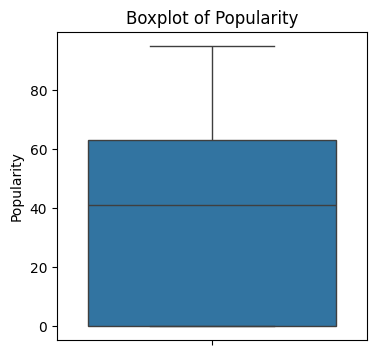

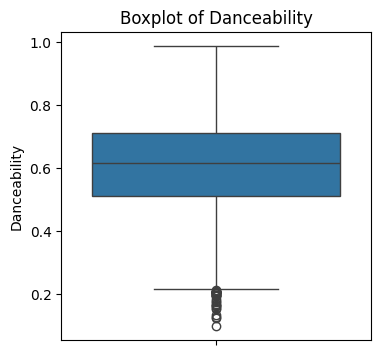

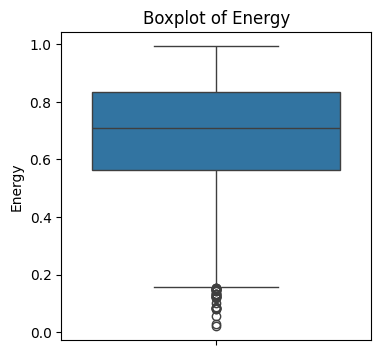

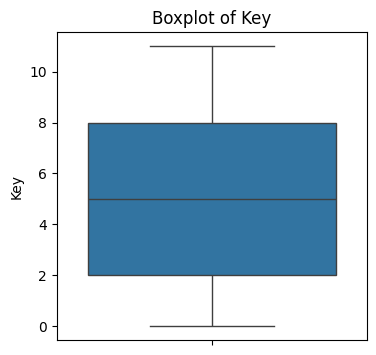

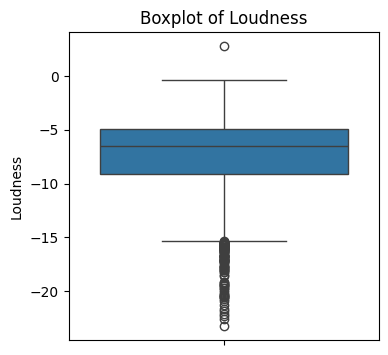

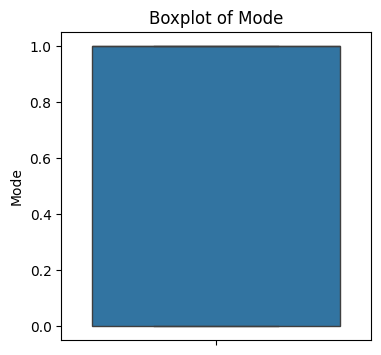

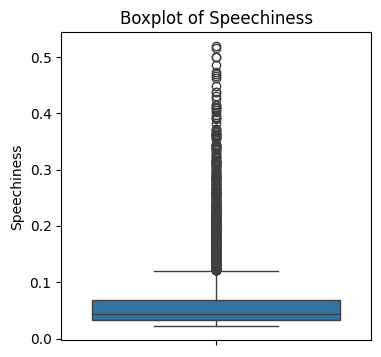

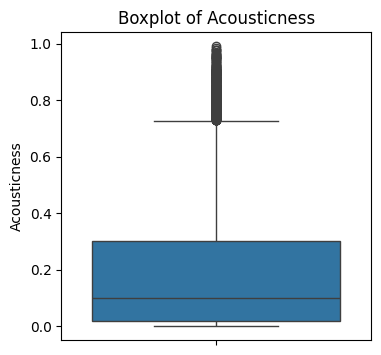

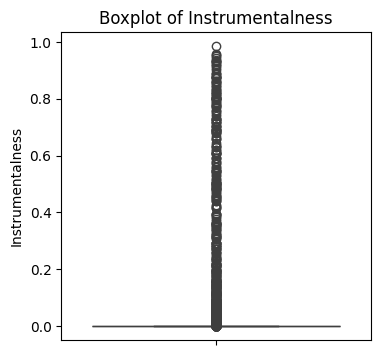

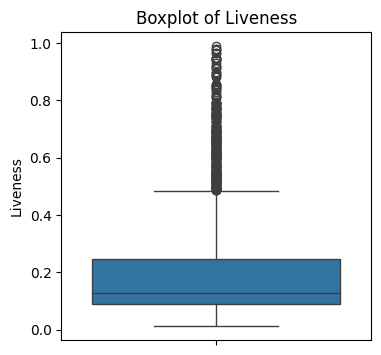

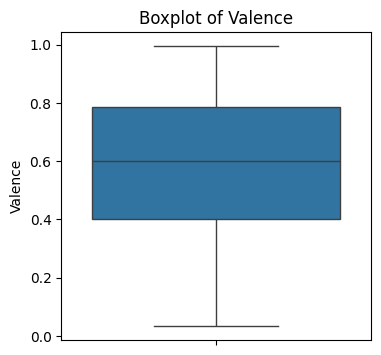

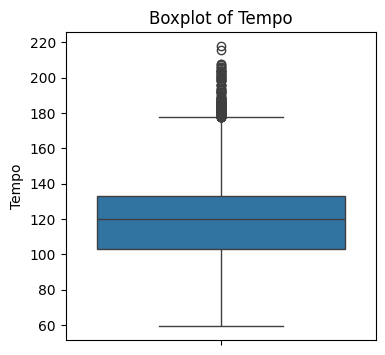

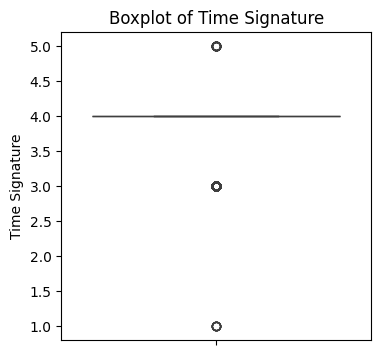

In [66]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(4, 4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [67]:
#untuk outliers di variabel numerical --> ganti dengan median

outlier_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_mild = Q1 - 1.5 * IQR
    upper_mild = Q3 + 1.5 * IQR

    lower_extreme = Q1 - 3.0 * IQR
    upper_extreme = Q3 + 3.0 * IQR

    median = df[col].median()

    df.loc[
        ((df[col] < lower_mild) & (df[col] >= lower_extreme)) |
        ((df[col] > upper_mild) & (df[col] <= upper_extreme)),
        col
    ] = median

In [68]:
#unique values sangat tinggi di Track URI --> normal, setiap track lagu berbeda (kecuali track yg sama title atau sama version) punya URI berbeda

cat_cols = df.select_dtypes(include=["object", "bool"]).columns

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())

#Track name banyak yang unique --> banyak nama lagu yang ada
#Artist name juga banyak yang unique --> banyak nama artis
#masalah ada di ARTIST GENRE --> banyak genre yang sama tapi penulisannya aja yang beda --> inconsistencies


Column: Track URI
['spotify:track:38tpcZDofjtDNunMm5w1EU'
 'spotify:track:60lJebAiPbIrnLeGev6kHX'
 'spotify:track:1dbt3sOwRmUOLfQZSpSz9O' ...
 'spotify:track:0TwxA1UTqCXyihWqu6PMWh'
 'spotify:track:0A4PZuepTcIQVvA5m7R0M1'
 'spotify:track:1oH5Mg9dyAj15lWUmXvmFW']

Column: Track Name
['If I Could Change Your Mind' "If I Ain't Got You" 'Truly' ...
 'Dreaming My Dreams with You' "Don't You (Forget About Me) - Remastered"
 'Cross Me (feat. Chance the Rapper & PnB Rock)']

Column: Artist Name(s)
['HAIM' 'Alicia Keys' 'Lionel Richie' ... 'Colleen Hewett' 'Simple Minds'
 'Ed Sheeran, Chance the Rapper, PnB Rock']

Column: Album Name
['Days Are Gone (Deluxe Edition)' 'The Diary Of Alicia Keys'
 'Lionel Richie (Expanded Edition)' ... 'Lost on You' 'Colleen'
 'Celebrate (Greatest Hits)']

Column: Album Release Date
['2013-01-01' '2003' '1982' ... '2012-06-01' '2008-01-25' '2013-03-25']

Column: Artist Genres
['indietronica,metropopolis' 'neo soul,pop,r&b' 'soft rock' ...
 'brill building pop,cla

In [69]:
#check buat artist genres
df["Artist Genres"].nunique()

1903

In [70]:
df['Artist Genres'].value_counts().head(20)

,count
Artist Genres,
unknown,294
"dance pop,pop",121
australian rock,116
pop,107
"australian pop,australian talent show",43
australian pop,39
"australian pop,australian rock",33
"australian alternative rock,australian rock",32
"rock-and-roll,rockabilly",31


In [71]:
df['Artist Genres'].apply(type).value_counts()

,count
Artist Genres,
<class 'str'>,4990


In [72]:
#masalah di Artist Genres --> inconsistent format / typing
# sebuah lagu ngga selalu fixed kepada 1 genre --> bisa banyak genre
# tapi beberapa typingnya salah --> tidak ada spasi setelah koma
#maka formatnya harus di standardize

df['Artist Genres'] = (
    df['Artist Genres']
    .str.lower().str.strip()) #buat capitalisation and leading string s

In [73]:
df['Artist Genres'] = df['Artist Genres'].str.split(',') #split stringnya kalau ada ","
#RUN SEKALI AJA SOALNYA GABISA STR LOWER ATAU STR STRIP SETELAH JADI LIST

In [74]:
df['Artist Genres'] = df['Artist Genres'].apply(
    lambda x: sorted(set(g.strip() for g in x))
)
#hilangin whitespace dan remove duplicate dalam listnya

In [75]:
#cek column Artist Genres skrg
df[['Track Name', 'Artist Name(s)', 'Artist Genres']].head(10)

,Track Name,Artist Name(s),Artist Genres
0,If I Could Change Your Mind,HAIM,"[indietronica, metropopolis]"
1,If I Ain't Got You,Alicia Keys,"[neo soul, pop, r&b]"
2,Truly,Lionel Richie,[soft rock]
3,I've Been Thinking About You,Londonbeat,"[eurodance, hip house]"
4,Kung Fu Fighting,"Bus Stop, Carl Douglas",[unknown]
5,Love Don't Cost a Thing,Jennifer Lopez,"[dance pop, pop, urban contemporary]"
6,Levels - Radio Edit,Avicii,"[edm, pop, pop dance]"
7,All Good Things (Come To An End) - Radio Edit,Nelly Furtado,"[canadian latin, canadian pop, dance pop, pop]"
8,Marry You,Bruno Mars,"[dance pop, pop]"
9,Over Now (with The Weeknd),"Calvin Harris, The Weeknd","[canadian contemporary r&b, canadian pop, danc..."


In [76]:
#Track URI, sbnernya ngga berkontribusi kepada model, itu cuman kode dari lagu, jadi bisa di exclude
#ngga boleh ikut ke encoding dibawah
df2 = df.drop(columns=['Track URI'])
df2.columns

Index(['Track Name', 'Artist Name(s)', 'Album Name', 'Album Release Date',
       'Popularity', 'Artist Genres', 'Danceability', 'Energy', 'Key',
       'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness',
       'Liveness', 'Valence', 'Tempo', 'Time Signature'],
      dtype='object')

### KESIMPULAN PREPROCESSING

MISSING VALUES

--> di Track Name, Artist Name(s), Album Name cuman 1, values ini kecil dibanding keseluruhan dataset, untuk prevent misinterpretasi model kita omit

--> Tempo & Acousticness: data numeric, impute missing values dengan median (tidak sensitif terhadap skewed data)

--> Genre: data kategoric --> biasanya di impute dengan mode, tetapi untuk reccomendation system kita avoid itu karena takut memperkuat bias mode genre --> maka kita impute dengan 'unknown'


DUPLICATE

--> kita ketemu 9, maka di drop aja karena jumlahnya kecil dibanding seluruh dataset


NUMERICAL OUTLIERS

--> replace outlier dengan median (tidak sensitif terhadap skewed data), keep EXTREME values (data masih bisa valuable)


CATEGORICAL UNIQUE & INCONSISTENCIES

--> masalah paling banyak di Artist Genres
--> 1 lagu bisa banyak genre --> penulisan genre salah (whitespace & format ,)

--> fix capitalisation dan string whitespace agar lebih uniform
--> remove duplicate yang ada dalam 1 lagu


TRACK URI

--> remove aja column ini dari df, karena tidak memberikan valuable information untuk recommendation system

### Visualisasi

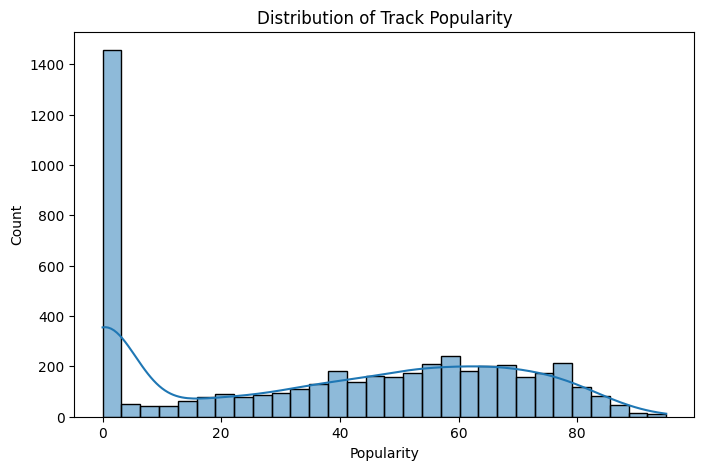

In [77]:
#lihat popularitas

plt.figure(figsize=(8,5))
sns.histplot(df2['Popularity'], bins=30, kde=True)
plt.title("Distribution of Track Popularity")
plt.show()

#distribusinya right skewed
#banyak lagu yang tidak populer
#dan hanya beberapa lagu yang populer banget --> didengar banyak org

In [78]:
df2.dtypes

#dari sini, audio features seperti dancability, energy, key, loudness --> semua float 64

,0
Track Name,object
Artist Name(s),object
Album Name,object
Album Release Date,object
Popularity,int64
Artist Genres,object
Danceability,float64
Energy,float64
Key,float64
Loudness,float64


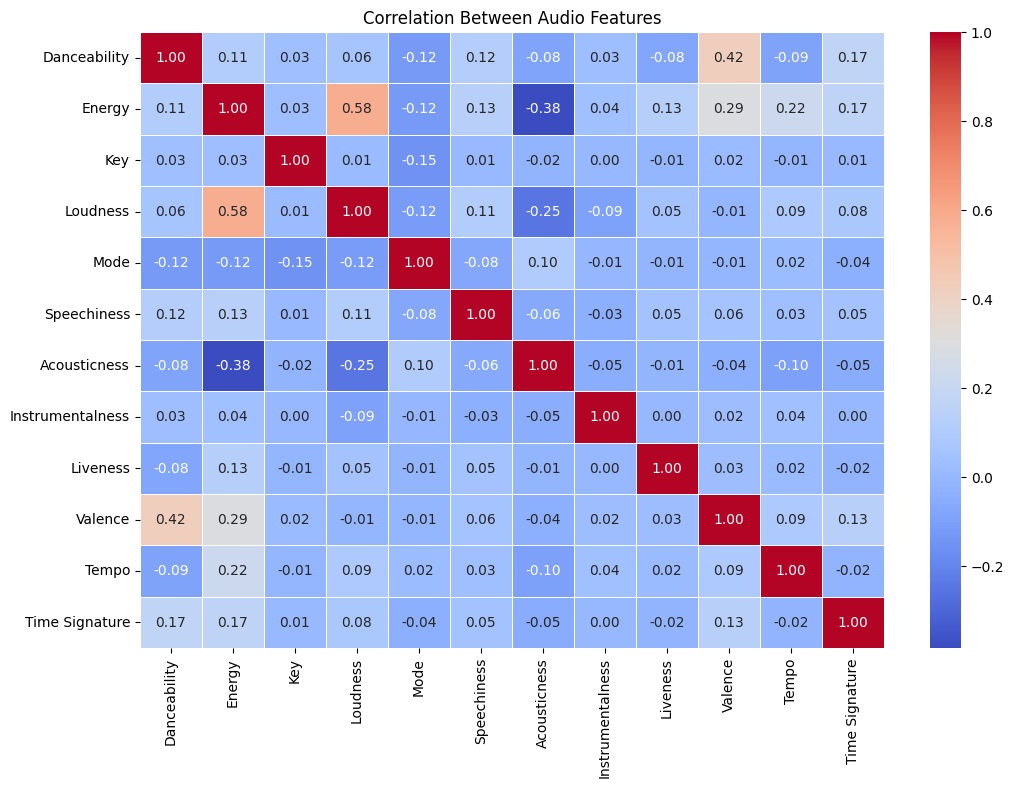

In [79]:
audio_features = df2.select_dtypes(include=["float64"]).columns


plt.figure(figsize=(12, 8))
sns.heatmap(
    df2[audio_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Between Audio Features")
plt.show()


In [80]:
genre_df = df2.explode('Artist Genres') #ini karena setiap lagu bisa banyak genre, kita pisah aja rownya, karena list, misalnya kalau
#1 lagu 3 genre, jadi 3 rows

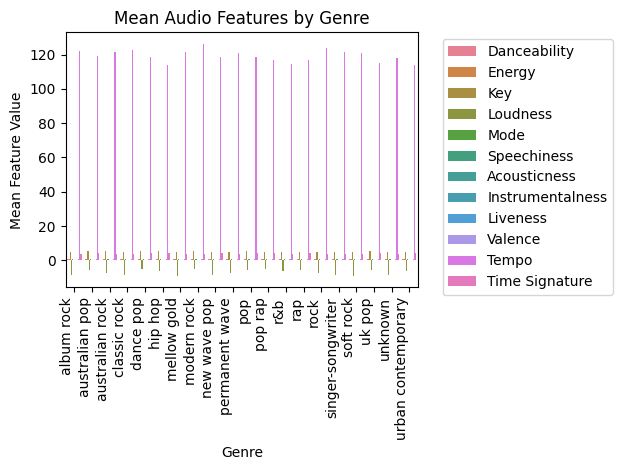

In [81]:
genre_counts = genre_df['Artist Genres'].value_counts()
valid = genre_counts[genre_counts >= 200].index #karena genre sangat banyak, keep aja genre" yang ada di lebih dari 20 lagu

genre_df = genre_df[genre_df['Artist Genres'].isin(valid)]

genre_means = (
    genre_df
    .groupby('Artist Genres')[audio_features]
    .mean()
)

genre_means2 = genre_means.reset_index().melt(
    id_vars='Artist Genres',
    value_vars=audio_features,
    var_name='Audio Feature',
    value_name='Mean Value'
)

sns.barplot(
    data=genre_means2,
    x='Artist Genres',
    y='Mean Value',
    hue='Audio Feature'
)

plt.xticks(rotation=90, ha='right')
plt.title('Mean Audio Features by Genre')
plt.xlabel('Genre')
plt.ylabel('Mean Feature Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [82]:
genre_counts = genre_df['Artist Genres'].value_counts()
major_genres = genre_counts[genre_counts >= 150].index

genre_df_major = genre_df[genre_df['Artist Genres'].isin(major_genres)]


genre_audio_means = (
    genre_df_major
    .groupby('Artist Genres')[audio_features]
    .mean()
    .round(3)
)

for genre, row in genre_audio_means.iterrows():
    print(f"\nGenre: {genre}")
    for feature, value in row.items():
        print(f"  {feature}: {value}")


Genre: album rock
  Danceability: 0.566
  Energy: 0.696
  Key: 5.003
  Loudness: -8.434
  Mode: 0.788
  Speechiness: 0.053
  Acousticness: 0.18
  Instrumentalness: 0.034
  Liveness: 0.176
  Valence: 0.638
  Tempo: 122.162
  Time Signature: 3.962

Genre: australian pop
  Danceability: 0.602
  Energy: 0.716
  Key: 5.64
  Loudness: -5.791
  Mode: 0.671
  Speechiness: 0.064
  Acousticness: 0.143
  Instrumentalness: 0.012
  Liveness: 0.16
  Valence: 0.537
  Tempo: 119.13
  Time Signature: 3.979

Genre: australian rock
  Danceability: 0.543
  Energy: 0.716
  Key: 5.431
  Loudness: -7.185
  Mode: 0.774
  Speechiness: 0.047
  Acousticness: 0.118
  Instrumentalness: 0.03
  Liveness: 0.17
  Valence: 0.578
  Tempo: 121.329
  Time Signature: 3.944

Genre: classic rock
  Danceability: 0.562
  Energy: 0.668
  Key: 4.935
  Loudness: -8.466
  Mode: 0.829
  Speechiness: 0.049
  Acousticness: 0.204
  Instrumentalness: 0.035
  Liveness: 0.18
  Valence: 0.646
  Tempo: 122.528
  Time Signature: 3.957

Gen

In [83]:
#karena genre masih ada banyak walaupun sudah dipilih yang lebih dari 150 lagu, lebih baik kita bikin sebagai dataframa aja
#lalu describe untuk liat rata" untuk semua lagu
#kita juga bisa liat yang max features di genre apa aja

dfgenre = genre_audio_means.copy()
#dfgenre.describe()

max_feature_genre = dfgenre.idxmax()
max_feature_genre


,0
Danceability,hip hop
Energy,modern rock
Key,australian pop
Loudness,modern rock
Mode,singer-songwriter
Speechiness,hip hop
Acousticness,mellow gold
Instrumentalness,unknown
Liveness,rap
Valence,new wave pop


In [84]:
for feature in dfgenre.columns:
    genre = dfgenre[feature].idxmax()
    value = dfgenre[feature].max()
    print(f"{feature}: {genre} ({value:.3f})")


Danceability: hip hop (0.735)
Energy: modern rock (0.797)
Key: australian pop (5.640)
Loudness: modern rock (-5.220)
Mode: singer-songwriter (0.862)
Speechiness: hip hop (0.154)
Acousticness: mellow gold (0.244)
Instrumentalness: unknown (0.066)
Liveness: rap (0.181)
Valence: new wave pop (0.662)
Tempo: modern rock (126.229)
Time Signature: hip hop (4.015)


In [85]:
max_genre_per_feature = dfgenre.idxmax()
max_value_per_feature = dfgenre.max()

max_summary = (
    pd.DataFrame({
        'Genre (Max)': max_genre_per_feature,
        'Max Value': max_value_per_feature
    })
)

max_summary

,Genre (Max),Max Value
Danceability,hip hop,0.735
Energy,modern rock,0.797
Key,australian pop,5.640
Loudness,modern rock,-5.220
Mode,singer-songwriter,0.862
Speechiness,hip hop,0.154
Acousticness,mellow gold,0.244
Instrumentalness,unknown,0.066
Liveness,rap,0.181
Valence,new wave pop,0.662


In [86]:
min_genre_per_feature = dfgenre.idxmin()
min_value_per_feature = dfgenre.min()

min_summary = (
    pd.DataFrame({
        'Genre (Min)': min_genre_per_feature,
        'Min Value': min_value_per_feature
    })
)

min_summary

,Genre (Min),Min Value
Danceability,modern rock,0.542
Energy,singer-songwriter,0.604
Key,urban contemporary,4.883
Loudness,soft rock,-9.081
Mode,hip hop,0.535
Speechiness,mellow gold,0.040
Acousticness,modern rock,0.071
Instrumentalness,pop rap,0.001
Liveness,modern rock,0.156
Valence,uk pop,0.494


In [87]:
for feature in dfgenre.columns:
    print(f"\nTop 3 genres by {feature}:")
    print(
        dfgenre[feature]
        .sort_values(ascending=False)
        .head(3)
    )


Top 3 genres by Danceability:
Artist Genres
hip hop    0.735
pop rap    0.710
rap        0.710
Name: Danceability, dtype: float64

Top 3 genres by Energy:
Artist Genres
modern rock       0.797
dance pop         0.747
permanent wave    0.738
Name: Energy, dtype: float64

Top 3 genres by Key:
Artist Genres
australian pop     5.640
australian rock    5.431
uk pop             5.340
Name: Key, dtype: float64

Top 3 genres by Loudness:
Artist Genres
modern rock   -5.220
pop rap       -5.286
dance pop     -5.311
Name: Loudness, dtype: float64

Top 3 genres by Mode:
Artist Genres
singer-songwriter    0.862
classic rock         0.829
mellow gold          0.829
Name: Mode, dtype: float64

Top 3 genres by Speechiness:
Artist Genres
hip hop    0.154
pop rap    0.135
rap        0.134
Name: Speechiness, dtype: float64

Top 3 genres by Acousticness:
Artist Genres
mellow gold          0.244
singer-songwriter    0.233
soft rock            0.216
Name: Acousticness, dtype: float64

Top 3 genres by Instr

### KESIMPULAN EDA

Distribusi Track Popularity

--> left skewed, banyak lagu yang ada dan tidak populer, namun setelah itu, data terlihat relatif normally distributed (bell curve shape), dan hanya sedikit lagu yang ada termasuk lagu yang sangat populer


HeatMap AudioFeatures

--> data" numeric jadi Audio Features: Loudness, Energy

--> dalam heatmap beberapa fitur audio berkorelasi, yang RELATIF lebih kuat adalah:

- Loudness & Energy : 0.58 (positively correlated)
- Valence & Dancability : 0.42 (slight positive correlation)
- Energy & Acousticnesss : - 0.38 (slight negative correlation)
- Loudness & Acoustidness : -0.25 (slight negative correlation)


Genre Dengan Max Value di Audio Features:
Danceability: hip hop (0.735)

Energy: modern rock (0.797)

Key: australian pop (5.640)

Loudness: modern rock (-5.220)

Mode: singer-songwriter (0.862)

Speechiness: hip hop (0.154)

Acousticness: mellow gold (0.244)

Instrumentalness: unknown (0.066)

Liveness: rap (0.181)

Valence: new wave pop (0.662)

Tempo: modern rock (126.229)

Time Signature: hip hop (4.015)


Genre dengan Min Value di Audio Features:
Danceability	modern rock	0.542

Energy	singer-songwriter	0.604

Key	urban contemporary	4.883

Loudness	soft rock	-9.081

Mode	hip hop	0.535

Speechiness	mellow gold	0.040

Acousticness	modern rock	0.071

Instrumentalness	pop rap	0.001

Liveness	modern rock	0.156

Valence	uk pop	0.494

Tempo	hip hop	113.970

Time Signature	r&b	3.941

### Bikin Reccomendation Systemnnya

In [89]:
df2 = df2.reset_index(drop=True) #karena sebelum ini kita sempet drop, dan remove Track URI, indexnya belum di reset , belum di kurangin
#jadi kita harus kurangin dulu di df barunya

In [107]:
#vectorise Artist Genres
#Term Frequency-Inverse Document Frequency
#mengubah teks menjadi vector value --> harus digunakan untuk recommendation system

df2['genres_text'] = df2['Artist Genres'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else ''
)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2
)

genre_tfidf = tfidf.fit_transform(df2['genres_text'])

In [109]:
scaler = StandardScaler()
audio_scaled = scaler.fit_transform(df2[audio_features])
#standardizes audio feature dengan scaling ke unit variance --> mean ~ 0, standard dev ~ 1
#Z-score normalization

In [111]:
content_matrix = hstack([genre_tfidf, audio_scaled]) #hstack dari scikit
content_matrix
#gabungkan yang sudah di TFIDD genre dan audio scaled secara horizontal --> tabel bergerak ke kanan

<COOrdinate sparse matrix of dtype 'float64'
	with 110949 stored elements and shape (4990, 1691)>

In [112]:
similarity_matrix = cosine_similarity(content_matrix) #cosine similarity
similarity_matrix #menghitung similaritas antar lagu melalui content matrix --> genre dan audio features

array([[ 1.        , -0.44456428, -0.46624034, ..., -0.5575691 ,
         0.39574794,  0.21952799],
       [-0.44456428,  1.        ,  0.44704099, ...,  0.45931174,
        -0.34212535,  0.02856643],
       [-0.46624034,  0.44704099,  1.        , ...,  0.91736696,
        -0.47963539, -0.07855133],
       ...,
       [-0.5575691 ,  0.45931174,  0.91736696, ...,  1.        ,
        -0.32135904, -0.09763508],
       [ 0.39574794, -0.34212535, -0.47963539, ..., -0.32135904,
         1.        ,  0.22993986],
       [ 0.21952799,  0.02856643, -0.07855133, ..., -0.09763508,
         0.22993986,  1.        ]])

In [115]:
#buat function reccomendation songnya

def recommend_song(song_title, top_n=5):

  #function documentationnya --> ttg functionnya
    """
    Song recommender
    Input  : song title (string)
    Output : DataFrame of recommended songs
    """

    #check, validasi kalau lagunya memang ada di df
    if song_title not in df2['Track Name'].values:
        raise ValueError(f"Song '{song_title}' not found in dataset.")

    #ambil index dari lagu yang dicari --> ambil row itu sebagai target
    song_idx = df2.index[df2['Track Name'] == song_title][0]

    similarity_scores = list(enumerate(similarity_matrix[song_idx])) #cek similarity score lagu" di df dengan target song

    #similaritynya di sort secara descending --> paling mirip ke lumayan mirip
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    #karena target songnya pasti paling mirip --> rank no 1, maka di remove
    similarity_scores = similarity_scores[1:top_n + 1]

    #index" yang menjadi reccomended
    recommended_indices = [i[0] for i in similarity_scores]

    audio_features = list(df2.select_dtypes(include=["float64"]).columns)

    result = df2.iloc[recommended_indices][['Track Name', 'Artist Name(s)', 'Album Name'] + audio_features]
    #format resultnya

    result = result.reset_index(drop=True)
    result.insert(0, 'Rank', range(1, len(result) + 1))

    return result


### Trial with 3 Song

In [116]:
recommend_song("Where The Boys Are")

,Rank,Track Name,Artist Name(s),Album Name,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,1,Too Much Love Will Kill You - Remastered 2011,Queen,Made In Heaven (2011 Remaster),0.385,0.395,7.0,-7.602,1.0,0.0313,0.580,0.000063,0.159,0.210,72.933,4.0
1,2,Strangers In The Night,Frank Sinatra,Strangers In The Night (Expanded Edition),0.259,0.473,5.0,-8.275,1.0,0.0295,0.592,0.000000,0.201,0.539,90.348,4.0
2,3,In the Ghetto,Elvis Presley,From Elvis in Memphis,0.404,0.266,10.0,-6.492,1.0,0.0334,0.716,0.133000,0.107,0.491,88.916,4.0
3,4,Always Together - Remastered,Al Martino,Crooner (Remastered),0.259,0.392,8.0,-8.794,1.0,0.0297,0.621,0.014500,0.233,0.366,105.402,4.0
4,5,I Don't Know How To Love Him,Helen Reddy,I Don't Know How To Love Him,0.284,0.396,3.0,-6.761,1.0,0.0280,0.699,0.038600,0.129,0.303,79.628,4.0


In [117]:
recommend_song("I'm On Fire")

,Rank,Track Name,Artist Name(s),Album Name,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,1,Lies,The Knickerbockers,Rockin'! with the Knickerbockers,0.493,0.830,4.0,-7.104,0.0,0.0316,0.449,0.0000,0.253,0.915,145.843,4.0
1,2,Poison Ivy,Billy Thorpe & The Aztecs,The Very Best Of,0.630,0.852,2.0,-6.520,0.0,0.0532,0.681,0.0000,0.292,0.914,130.105,4.0
2,3,Antisocial (with Travis Scott),"Ed Sheeran, Travis Scott",No.6 Collaborations Project,0.715,0.823,5.0,-5.313,0.0,0.0495,0.133,0.0000,0.361,0.910,151.956,4.0
3,4,I Saw Her Again - Single Version,The Mamas & The Papas,The Mamas & The Papas,0.476,0.860,1.0,-5.976,0.0,0.0331,0.171,0.0309,0.235,0.894,121.715,4.0
4,5,Bang Bang,"Jessie J, Ariana Grande, Nicki Minaj",Sweet Talker (Deluxe Version),0.711,0.774,0.0,-3.391,0.0,0.0922,0.259,0.0000,0.371,0.715,150.032,4.0


In [118]:
recommend_song("Blowin' in the Wind")

,Rank,Track Name,Artist Name(s),Album Name,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,1,Keep on Loving You,REO Speedwagon,Hi Infidelity (30th Anniversary Edition),0.306,0.722,0.0,-5.963,1.0,0.0340,0.05190,0.000000,0.1170,0.410,174.732,4.0
1,2,Blowin' in the Wind,"Peter\, Paul and Mary",In the Wind,0.381,0.710,5.0,-6.492,1.0,0.0320,0.09820,0.000000,0.1120,0.557,155.036,4.0
2,3,Lonely Boy,The Black Keys,El Camino,0.356,0.872,2.0,-7.837,1.0,0.0680,0.00417,0.009750,0.0997,0.607,166.300,4.0
3,4,Blinding Lights,The Weeknd,After Hours,0.514,0.730,1.0,-5.934,1.0,0.0598,0.00146,0.000095,0.0897,0.334,171.005,4.0
4,5,Welcome to My Life,Simple Plan,Still Not Getting Any,0.421,0.858,1.0,-4.535,1.0,0.0963,0.01340,0.000000,0.0670,0.491,173.255,4.0


### KESIMPULAN RECCOMENDATION SYSTEM

Recommendation system dibuat menggunakan function based on TFIDF Artist Genre, untuk vectorise string menjadi salah satu fitur di reccomendation system dan cosine similarity matrix dari Audio Features yang sudah melalui proses standard scaler ~normal. Content matrix dibuat untuk menggabungkan hasil Artist Genre tfidf dan audio features standard scalar untuk membuat matrix inti yang akan menjadi perbandingan di similarity matrix dengan target song. cosine similarity di operasikan kepada similarity matrix. Dalam functionnya sendiri, hasil similarity matrix ini akan di enumerate dalam list dan di order secara descending --> yang mana yang nilainya paling mirip dengan nilai content matrix target song. dari lagu" yang paling cocok, indexnya akan di ambil --> content matrix, fitur yang ada di lagu reccomendasi, akan di display secara descending dengan Track Name, Artist Name(s), Album Name dan Audio Featuresnya